In [1]:
import geopandas as gpd
import fiona

# Path to swissTLM3D, swissBOUNDARIES3D and Corine Land Cover
tlm_path = "C:/ZHAW/5.Semester/PA2/data/SWISSTLM3D_2025.gpkg"
boundaries_path = "C:/ZHAW/5.Semester/PA2/data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"
clc_path = "C:/ZHAW/5.Semester/PA2/data/Results/U2018_CLC2018_V2020_20u1.gpkg"


# List all layers
layers = fiona.listlayers(tlm_path)
print(f"tlm layers: {layers}")  
layers = fiona.listlayers(boundaries_path)
print(f"boundary layers: {layers}") 
layers = fiona.listlayers(clc_path)
print(f"clc layers: {layers}")

tlm layers: ['tlm_strassen_aus_einfahrt', 'tlm_bb_bodenbedeckung', 'tlm_bb_einzelbaum_gebuesch', 'tlm_eo_einzelobjekt', 'tlm_oev_eisenbahn', 'tlm_gewaesser_fliessgewaesser', 'tlm_namen_flurname', 'tlm_areale_freizeitareal', 'tlm_bauten_gebaeude_footprint', 'tlm_namen_gebietsname', 'tlm_name_gelaendename', 'tlm_oev_haltestelle', 'tlm_bauten_leitung', 'tlm_bauten_mauer', 'tlm_namen_name_pkt', 'tlm_areale_nutzungsareal', 'tlm_oev_schifffahrt', 'tlm_areale_schutzgebiet', 'tlm_namen_siedlungsname', 'tlm_bauten_sportbaute_lin', 'tlm_bauten_sportbaute_ply', 'tlm_bauten_staubaute', 'tlm_gewaesser_stehendes_gewaesser', 'tlm_strassen_strasse', 'tlm_strassen_strasseninfo', 'tlm_oev_uebrige_bahn', 'tlm_bauten_verbauung', 'tlm_areale_verkehrsareal', 'tlm_bauten_verkehrsbaute_lin', 'tlm_bauten_verkehrsbaute_ply', 'tlm_bauten_versorgungsbaute_pkt', 'tlm_bb_glamos', 'tlm_bauten_leitung_stromtrasse', 'tlm_areale_nutzungsareal_schule', 'tlm_areale_schule', 'tlm_strassen_strassenname', 'tlm_strassen_stra

SwissTLM3d daten laden

In [2]:
def load_swisstlm_for_canton(layername, bbox, canton):
    tlm_path = "C:/ZHAW/5.Semester/PA2/data/SWISSTLM3D_2025.gpkg"
    layer = gpd.read_file(tlm_path, layer=layername, bbox=bbox)
    canton_layer = gpd.clip(layer, canton)
    return canton_layer



def filter_canton(cantonname):
    boundaries_path = "C:/ZHAW/5.Semester/PA2/data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"
    cantons = gpd.read_file(boundaries_path, layer="tlm_kantonsgebiet")
    canton = cantons[cantons["name"] == cantonname]
    xmin, ymin, xmax, ymax = canton.total_bounds
    canton_bbox = (xmin, ymin, xmax, ymax)
    return canton, canton_bbox


Generate canton boundaries and bounding box

In [3]:
sh, sh_bbox = filter_canton("Schaffhausen")

Landcover

SwissTLM3d

<Axes: >

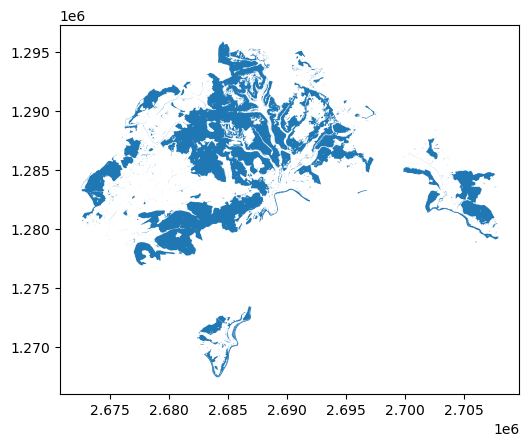

In [4]:
# load swisstlm data
landcover_sh = load_swisstlm_for_canton("tlm_bb_bodenbedeckung", sh_bbox, sh)

landcover_sh.plot()

Corine Landcover

In [ ]:
import pandas as pd

# load Corine Landcover data
landcover_sh_clc = gpd.read_file("C:/ZHAW/5.Semester/PA2/data/Results/U2018_CLC2018_V2020_20u1.gpkg", layer="U2018_CLC2018_V2020_20u1")

# load CLC_legend.csv
clc_legend = pd.read_csv("C:/ZHAW/5.Semester/PA2/data/Results/Info/Legend/Vector/CLC_legend.csv", sep=';')

Change datatyp to merge with legend

In [7]:
print(type(landcover_sh_clc["Code_18"][1]))

# change datatype
landcover_sh_clc['Code_18'] = landcover_sh_clc['Code_18'].astype(int)

print(type(landcover_sh_clc["Code_18"][1]))

<class 'str'>
<class 'numpy.int64'>


In [8]:
# Add the landcovernames to the data
landcover_sh_clc = landcover_sh_clc.merge(
    clc_legend[['CLC_CODE', 'LABEL3']],
    left_on='Code_18',
    right_on='CLC_CODE',
    how='left'
)

In [9]:
print(landcover_sh_clc.head())

   OBJECTID  Code_18 Remark     Area_Ha  Shape_Length    Shape_Area  \
0   1017625      112   None   80.820126   7055.077298  8.082013e+05   
1   1017783      112   None  161.691835  10461.377355  1.616918e+06   
2   1017791      112   None    0.146694    271.229232  1.466945e+03   
3   1017795      112   None  161.120051  10432.388571  1.611201e+06   
4   1017799      112   None   27.522222   3144.386954  2.752222e+05   

                                            geometry  CLC_CODE  \
0  MULTIPOLYGON (((8.57405 47.57627, 8.57286 47.5...       112   
1  MULTIPOLYGON (((8.86286 47.65489, 8.85973 47.6...       112   
2  MULTIPOLYGON (((8.43461 47.65998, 8.43366 47.6...       112   
3  MULTIPOLYGON (((8.87462 47.6598, 8.87446 47.65...       112   
4  MULTIPOLYGON (((8.49465 47.66356, 8.49619 47.6...       112   

                       LABEL3  
0  Discontinuous urban fabric  
1  Discontinuous urban fabric  
2  Discontinuous urban fabric  
3  Discontinuous urban fabric  
4  Discontinuous

In [10]:
import numpy as np

# print all landcovertypes in clc data
print(np.unique(landcover_sh_clc["LABEL3"]))

['Broad-leaved forest' 'Complex cultivation patterns' 'Coniferous forest'
 'Discontinuous urban fabric' 'Industrial or commercial units'
 'Land principally occupied by agriculture, with significant areas of natural vegetation'
 'Mineral extraction sites' 'Mixed forest' 'Non-irrigated arable land'
 'Pastures' 'Road and rail networks and associated land' 'Vineyards'
 'Water bodies' 'Water courses']


Show Landcover

In [11]:
# check the CRS of SwissTLM3D data:
print("CRS of SwissTLM3D:", landcover_sh.crs)

# check the CRS of Corine Landcover data:
print("CRS of Corine Landcover:", landcover_sh_clc.crs)

CRS of SwissTLM3D: EPSG:2056
CRS of Corine Landcover: EPSG:4326


In [12]:
landcover_sh_clc_proj = landcover_sh_clc.to_crs(landcover_sh.crs)

# To check the CRS of your Corine Landcover data:
print("CRS of Corine Landcover:", landcover_sh_clc_proj.crs)

CRS of Corine Landcover: EPSG:2056


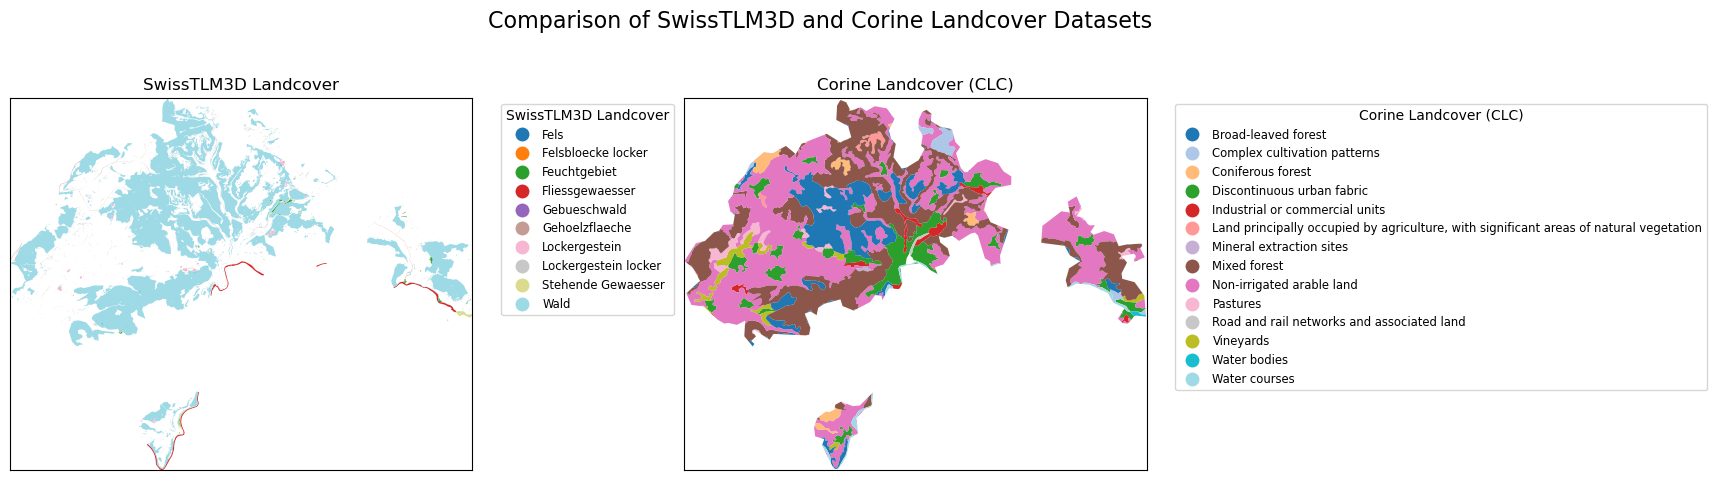

In [13]:
import matplotlib.pyplot as plt

# Set up the figure and two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 5)) # Increased width for external legends

# Plot 1: SwissTLM3D Landcover
landcover_sh.plot(
    column='objektart', 
    ax=axes[0], 
    legend=True, 
    legend_kwds={
        'title': "SwissTLM3D Landcover",
        'loc': 'upper left',       # Anchor the legend in the upper left corner of the bbox
        'bbox_to_anchor': (1.05, 1), # Position it to the right of the axes[0] plot
        'fontsize': 'small'
    },
    cmap='tab20'
)
axes[0].set_title('SwissTLM3D Landcover')

# Plot 2: Corine Landcover (CLC)
landcover_sh_clc_proj.plot(
    column='LABEL3',
    ax=axes[1],
    legend=True,
    legend_kwds={
        'title': "Corine Landcover (CLC)",
        'loc': 'upper left',       # Anchor the legend in the upper left corner of the bbox
        'bbox_to_anchor': (1.05, 1), # Position it to the right of the axes[1] plot
        'fontsize': 'small'
    },
    cmap='tab20'
)
axes[1].set_title('Corine Landcover (CLC)')

# **Optional but recommended:** Set common map limits if comparing the same area
# Use the bounds of the more detailed dataset (SwissTLM3D) to zoom in the view
x_min, y_min, x_max, y_max = landcover_sh.total_bounds
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

# Remove axis labels/ticks for a cleaner map look
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

# Display the plots
plt.suptitle("Comparison of SwissTLM3D and Corine Landcover Datasets", fontsize=16)
# Use 'tight_layout' to automatically adjust subplots and make room for the legends.
# Note: Since we've used bbox_to_anchor, we often rely on tight_layout to finalize spacing.
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

Fill SwissTLM Landcover with Corine Landcover

https://gdal.org/en/stable/programs/gdal_vector_rasterize.html#gdal-vector-rasterize

In [66]:
type(landcover_sh_clc_proj)

geopandas.geodataframe.GeoDataFrame

In [14]:
import geopandas as gpd
import pandas as pd

# Calculate the area of CLC that overlaps the SwissTLM3D area
# The 'overlay' function with how='difference' gives us the parts of CLC that DO NOT intersect swisstlm_boundary.
clc_fill_areas = gpd.overlay(landcover_sh_clc_proj, landcover_sh, how='difference', keep_geom_type=False)

# Rename the CLC attribute column in the filler data

# Identify the columns needed for the final combined GeoDataFrame
# 'LABEL3' contains the description you want. We map it to 'objektart' for consistency.
clc_fill_areas = clc_fill_areas.rename(columns={'LABEL3': 'objektart'})
# Keep only the necessary columns and the geometry, similar to the base layer
clc_fill_areas = clc_fill_areas[['objektart', 'geometry']]


# 3. Combine/Merge the two datasets
#    The base layer (SwissTLM3D) plus the 'hole filler' layer (CLC)
landcover_filled = pd.concat([landcover_sh[['objektart', 'geometry']], clc_fill_areas])

# Set the result as a GeoDataFrame (for safety) and re-index
landcover_filled = gpd.GeoDataFrame(landcover_filled, crs=landcover_sh.crs)
landcover_filled.reset_index(drop=True, inplace=True)

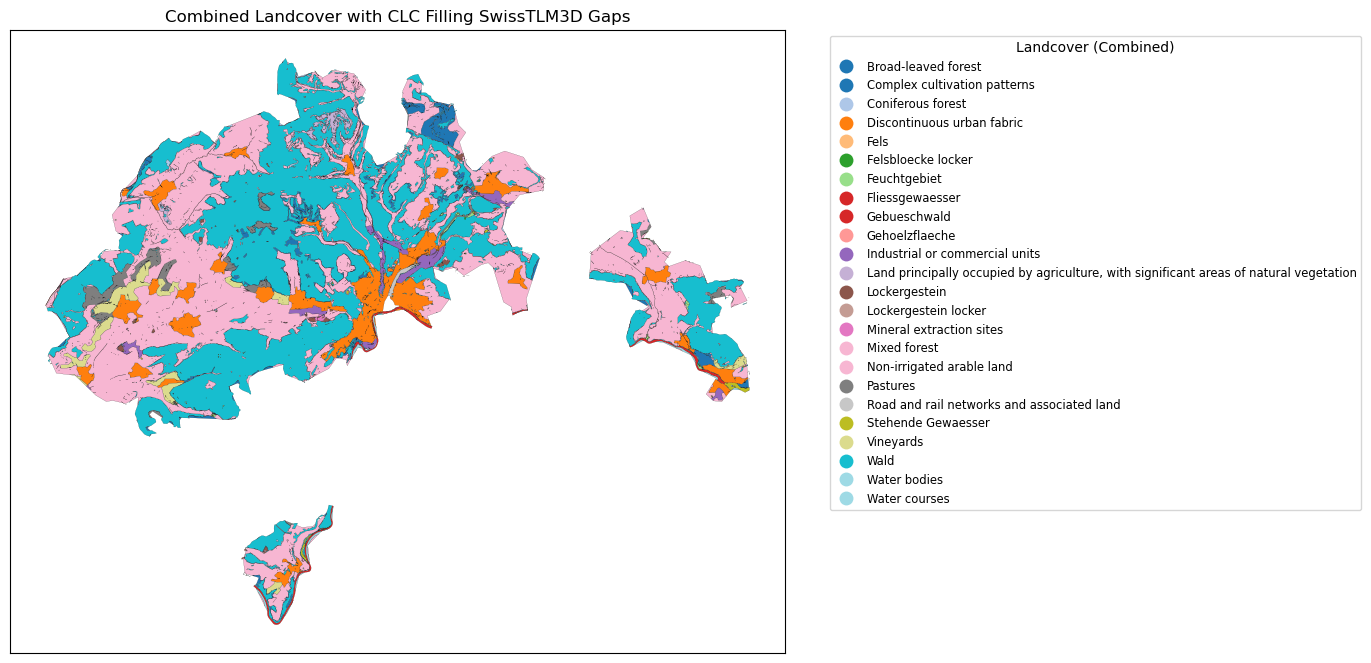

In [15]:
# Visualize the resulting map with filled holes
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

landcover_filled.plot(
    column='objektart', 
    ax=ax, 
    legend=True, 
    legend_kwds={
        'title': "Landcover (Combined)",
        'loc': 'upper left',
        'bbox_to_anchor': (1.05, 1),
        'fontsize': 'small'
    },
    cmap='tab20',
    edgecolor='black', 
    linewidth=0.1
)

ax.set_title('Combined Landcover with CLC Filling SwissTLM3D Gaps')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

plt.show()

In [16]:
np.unique(landcover_filled["objektart"])

array(['Broad-leaved forest', 'Complex cultivation patterns',
       'Coniferous forest', 'Discontinuous urban fabric', 'Fels',
       'Felsbloecke locker', 'Feuchtgebiet', 'Fliessgewaesser',
       'Gebueschwald', 'Gehoelzflaeche', 'Industrial or commercial units',
       'Land principally occupied by agriculture, with significant areas of natural vegetation',
       'Lockergestein', 'Lockergestein locker',
       'Mineral extraction sites', 'Mixed forest',
       'Non-irrigated arable land', 'Pastures',
       'Road and rail networks and associated land', 'Stehende Gewaesser',
       'Vineyards', 'Wald', 'Water bodies', 'Water courses'], dtype=object)

In [17]:
harmonization_map = {
    # --- Forest / Wooded Areas ---
    'Broad-leaved forest': 'Forest',
    'Coniferous forest': 'Forest',
    'Mixed forest': 'Forest',
    'Wald': 'Forest',
    'Gebueschwald': 'Scrub / Bushland',
    'Gehoelzflaeche': 'Scrub / Bushland', 
    
    # --- Agricultural Areas ---
    'Complex cultivation patterns': 'Agriculture',
    'Non-irrigated arable land': 'Agriculture',
    'Vineyards': 'Agriculture',
    'Pastures': 'Pastures',
    'Land principally occupied by agriculture, with significant areas of natural vegetation': 'Mixed Agriculture / Natural',
    
    # --- Artificial Areas ---
    'Discontinuous urban fabric': 'Urban Fabric',
    'Industrial or commercial units': 'Industrial / Commercial',
    'Road and rail networks and associated land': 'Infrastructure',
    'Mineral extraction sites': 'Extraction Sites',
    
    # --- Natural / Semi-natural Areas ---
    'Feuchtgebiet': 'Wetland',
    'Fels': 'Bare Rock / Scree',
    'Felsbloecke locker': 'Bare Rock / Scree',
    'Lockergestein': 'Bare Rock / Scree',
    'Lockergestein locker': 'Bare Rock / Scree',

    # --- Water (TO BE DELETED/FILTERED) ---
    'Fliessgewaesser': 'Water',
    'Stehende Gewaesser': 'Water',
    'Water bodies': 'Water',
    'Water courses': 'Water'
}


In [18]:
# Create the new standardized column
landcover_filled['Standard_LC_Name'] = landcover_filled['objektart'].map(harmonization_map)

# Remove Objektart column
landcover_filled.drop(columns="objektart")

# Filter the data to exclude all rows categorized as 'Water'
# This removes 'Fliessgewaesser', 'Stehende Gewaesser', 'Water bodies', and 'Water courses'.
landcover_filtered = landcover_filled[landcover_filled['Standard_LC_Name'] != 'Water'].copy()


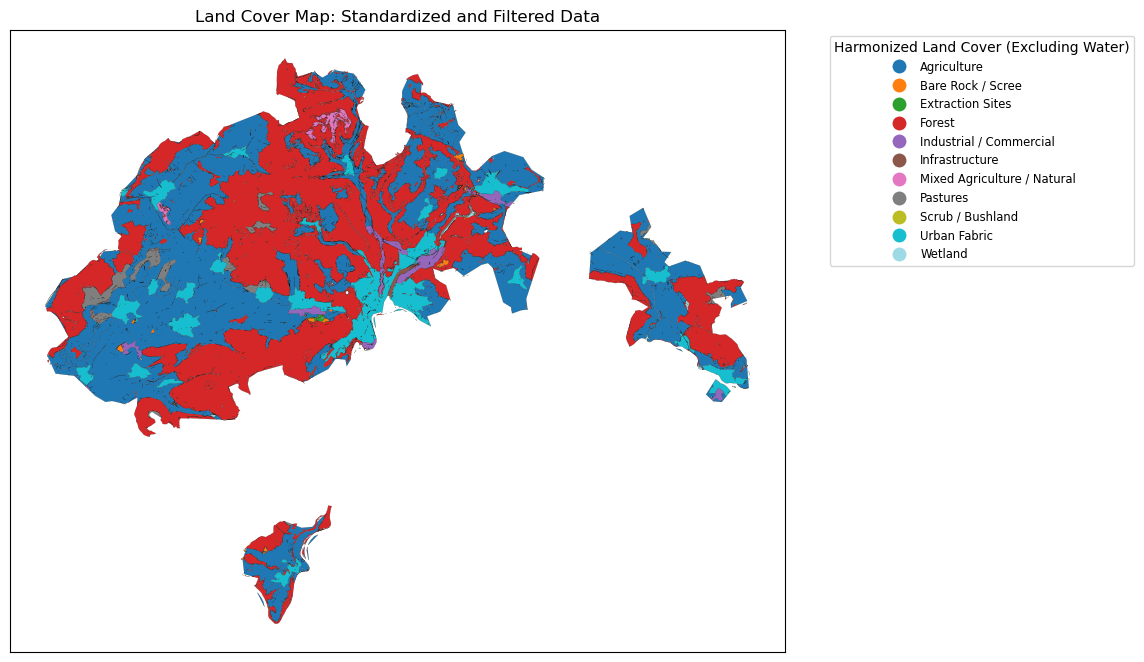

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot the filtered GeoDataFrame using the new standardized names
landcover_filtered.plot(
    column='Standard_LC_Name', 
    ax=ax, 
    legend=True, 
    legend_kwds={
        'title': "Harmonized Land Cover (Excluding Water)",
        'loc': 'upper left',
        'bbox_to_anchor': (1.05, 1), # Place legend outside the plot area
        'fontsize': 'small'
    },
    cmap='tab20', # Reusing a categorical color map
    edgecolor='black', 
    linewidth=0.1
)

ax.set_title('Land Cover Map: Standardized and Filtered Data')

# Remove axis elements for a map view
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

plt.show()

Cost Surfaces

In [20]:
# Cost Values for Landcover
cost_values = {
    'Pastures': 6,
    'Agriculture': 7,
    'Infrastructure': 9,
    'Urban Fabric': 10,
    'Industrial / Commercial': 10,
    'Mixed Agriculture / Natural': 3,
    'Scrub / Bushland': 1,
    'Forest': 2,
    'Wetland': 5,
    'Bare Rock / Scree': 4,
    'Extraction Sites': 8
}

# Apply the cost mapping to a new column in your GeoDataFrame
landcover_filtered['cost_value'] = landcover_filtered['Standard_LC_Name'].map(cost_values)

In [21]:
import numpy as np
from rasterio.features import rasterize
from rasterio.transform import from_bounds

def rasterize_vectordata(data, bbox, resolution_m = 10):
    width_in_meters = bbox[2] - bbox[0]
    height_in_meters = bbox[3] - bbox[1]

    # Calculate rows and columns based on the fixed bounds and resolution
    cols = int(np.ceil(width_in_meters / resolution_m))
    rows = int(np.ceil(height_in_meters / resolution_m))
    out_shape = (rows, cols)

    # Calculate the affine transform
    transform = from_bounds(bbox[0], bbox[1], bbox[2], bbox[3], cols, rows)

    shapes = [(geom, value) for geom, value in zip(data.geometry, data.cost_value.fillna(0)) if value > 0]
    
    # Create an empty array
    NA_VALUE = 0
    # Ändern Sie dtype zu einem Gleitkomma-Typ (float32 oder float64)
    raster_array = np.full(out_shape, NA_VALUE, dtype=np.float32)

    cost_surface = rasterize(
        shapes=shapes,
        out=raster_array,
        transform=transform,
        all_touched=True,
        dtype=np.int16
    )
    
    return cost_surface
    

# def create_cost_raster()

In [22]:
cost_surface_landcover=rasterize_vectordata(data = landcover_filtered, bbox = sh_bbox)

In [23]:


# def create_cost_raster(gdf, cost_column, resolution_m = 10, fill_value=0):
#     """
#     Rasterizes a GeoDataFrame's cost values onto a NumPy array grid.

#     Args:
#         gdf (GeoDataFrame): The input GeoDataFrame (e.g., landcover_filtered, water_combined).
#         cost_column (str): The name of the column containing the standardized cost values (1-10).
#         resolution_m (int): The target resolution for the raster cells in meters (e.g., 10).
#         total_bounds (tuple, optional): (xmin, ymin, xmax, ymax) of the definitive overall extent. 
#                                         If None, uses the bounds of the input GDF.
#         fill_value (int, optional): The No-Data value for areas outside the features. Defaults to 0.

#     Returns:
#         tuple: (NumPy array of the cost surface, Affine transform, out_shape, bounds)
#     """
    
#     # 1. Define the Extent and Dimensions (crucial for alignment)
    
#     # Use the provided total bounds or the GDF's own bounds
#     xmin, ymin, xmax, ymax = sh.total_bounds

#     width_in_meters = xmax - xmin
#     height_in_meters = ymax - ymin
    
#     # Calculate rows and columns based on the fixed bounds and resolution
#     cols = int(np.ceil(width_in_meters / resolution_m))
#     rows = int(np.ceil(height_in_meters / resolution_m))

#     out_shape = (rows, cols)
    
#     # Calculate the affine transform
#     transform = from_bounds(xmin, ymin, xmax, ymax, cols, rows)
    
#     # 2. Prepare Data for Rasterization
    
#     # Create (geometry, value) tuples, filtering out NaN values
#     # We use fillna(fill_value) for safety, but check against > 0 to exclude 
#     # areas that shouldn't be rasterized (e.g., non-cost features).
#     shapes = [
#         (geom, value)
#         for geom, value in zip(gdf.geometry, gdf[cost_column].fillna(fill_value))
#         if value > fill_value # Only rasterize features with a positive cost
#     ]

#     # 3. Rasterize the Cost Values
#     NA_VALUE = np.nan
#     # Ändern Sie dtype zu einem Gleitkomma-Typ (float32 oder float64)
#     raster_array = np.full(out_shape, NA_VALUE, dtype=np.float32)
    
#     cost_surface = rasterize(
#         shapes=shapes,
#         out=raster_array, # Burn into the existing array
#         transform=transform,
#         fill=fill_value,
#         all_touched=True,
#         dtype=np.int16
#     )
    
#     return (cost_surface, transform, out_shape, (xmin, ymin, xmax, ymax))

In [24]:
# import geopandas as gpd
# import rasterio
# from rasterio.features import rasterize
# from rasterio.transform import from_bounds
# import matplotlib.pyplot as plt
# import numpy as np

# # Define the target resolution in meters (e.g., 20m)
# resolution_meters = 10

# # Get the bounding box of your data
# xmin, ymin, xmax, ymax = landcover_filtered.total_bounds

# # Determine the number of rows and columns based on the bounding box and resolution
# width_in_meters = xmax - xmin
# height_in_meters = ymax - ymin
# cols = int(np.ceil(width_in_meters / resolution_meters))
# rows = int(np.ceil(height_in_meters / resolution_meters))

# # Calculate the affine transform (maps pixel coordinates to geographic coordinates)
# transform = from_bounds(xmin, ymin, xmax, ymax, cols, rows)

# # Create an empty output array initialized with NoData value (e.g., 0)
# out_shape = (rows, cols)
# fill_value = 0 # Areas without defined landcover will have this value
# raster_array = np.full(out_shape, fill_value, dtype=np.int16)

# # Prepare the data for rasterize: (geometry, value) tuples
# shapes = [(geom, value) for geom, value in zip(landcover_filtered.geometry, landcover_filtered.Cost_Value)]

In [25]:
# # Use rasterio.features.rasterize to create the cost surface
# cost_surface_landcover = rasterize(
#     shapes=shapes,
#     out_shape=out_shape,
#     transform=transform,
#     fill=fill_value,
#     all_touched=True, # Includes all pixels touched by the feature, not just the center
#     dtype=np.int16
# )

# print("Cost Surface (NumPy Array) created with shape:", cost_surface_landcover.shape)

In [26]:
# cost_surface_landcover = np.ma.masked_where(cost_surface_landcover == fill_value, cost_surface_landcover)

In [59]:
def visualize_cost_surface(data, cost_type, bbox):
    """
    Visualisiert eine Kostenoberfläche als Heatmap.
    
    :param data: Das 2D NumPy-Array der Kostenoberfläche.
    :param cost_type: Der Titel der Kostenoberfläche.
    :param sh_bbox: Bounding Box [xmin, xmax, ymin, ymax] für extent.
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    cmap_name = 'RdYlGn_r'
    
    # 1. Colormap kopieren und die Farbe für 'schlechte/maskierte' Daten setzen
    # Wir erstellen eine Kopie, um die globale Colormap nicht zu verändern
    cmap = plt.cm.get_cmap(cmap_name).copy() 
    cmap.set_bad('white') 
    
    # 2. Maskiertes Array erstellen: Alle 0-Werte maskieren (als ungültig behandeln)
    masked_data = np.ma.masked_where(data == 0, data)
    
    image = ax.imshow(
    masked_data, # Verwende das maskierte Array
    cmap=cmap,              
    extent=[sh_bbox[0], sh_bbox[1], sh_bbox[2], sh_bbox[3]],
    vmin=1,
    vmax=10)

    cbar = fig.colorbar(
    image, 
    ax=ax, 
    ticks=np.arange(1, 11, 1),
    shrink=0.5,
    aspect=30)
    
    cbar.set_label('Relative Movement Cost (Resistance)')
    
    # Achsenelemente für Kartenansicht entfernen
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

    ax.set_title(f'Cost Surface Map - {cost_type}')

    plt.tight_layout()

C:\Users\Lukas\AppData\Local\Temp\ipykernel_4720\3080590101.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


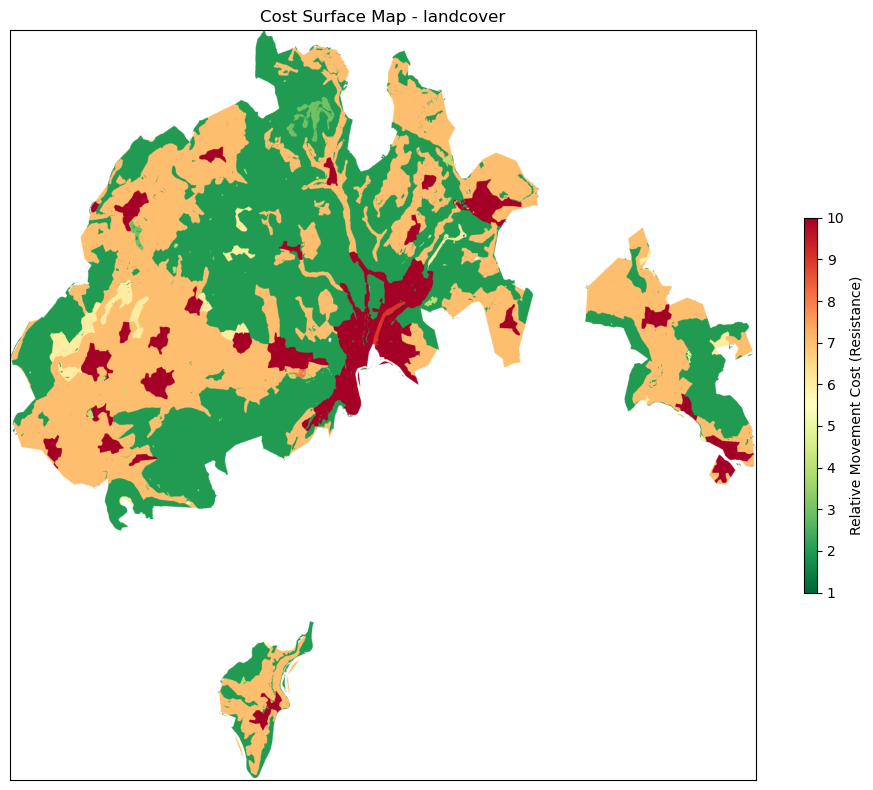

In [64]:
visualize_cost_surface(cost_surface_landcover, 'landcover', sh_bbox)

Water

In [29]:
# load swisstlm data
f_water_sh = load_swisstlm_for_canton("tlm_gewaesser_fliessgewaesser", sh_bbox, sh)
s_water_sh = load_swisstlm_for_canton("tlm_gewaesser_stehendes_gewaesser", sh_bbox, sh)

print(len(f_water_sh))
print(f_water_sh.head())

1938
                                        uuid datum_aenderung datum_erstellung  \
2410  {CECA776E-2226-40BD-A33B-8A9BA92D1CA5}      2019-09-23       2015-03-03   
2416  {F61F0703-18B7-4CA7-9E46-B27862344E4E}      2015-03-03       2015-03-03   
2415  {7B4B820D-F65D-4F60-87F0-79431423D368}      2015-03-03       2015-03-03   
2663  {0A6181A2-C0EA-45B6-85D4-734A3EDD6624}      2019-03-21       2008-01-25   
2668  {FBD77EA6-FCF1-4AC2-A9F8-49E90F9AEA55}      2017-01-06       2008-01-25   

      erstellung_jahr  erstellung_monat grund_aenderung   herkunft  \
2410             2014               6.0      Verbessert  swisstopo   
2416             2014               6.0      Verbessert  swisstopo   
2415             2014               6.0      Verbessert  swisstopo   
2663             2000               5.0      Verbessert  swisstopo   
2668             2000               NaN      Verbessert  swisstopo   

      herkunft_jahr  herkunft_monat        objektart  ...  \
2410           2019       

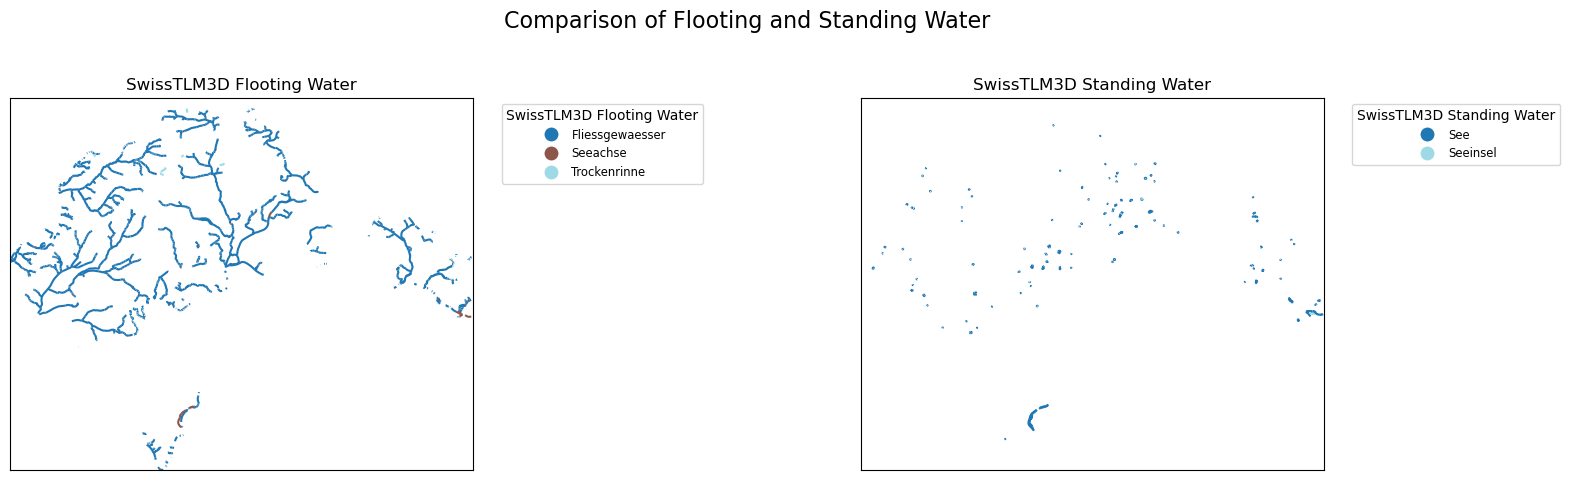

In [30]:
import matplotlib.pyplot as plt

# Set up the figure and two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 5)) # Increased width for external legends

# Plot 1: SwissTLM3D Landcover
f_water_sh.plot(
    column='objektart', 
    ax=axes[0], 
    legend=True, 
    legend_kwds={
        'title': "SwissTLM3D Flooting Water",
        'loc': 'upper left',       # Anchor the legend in the upper left corner of the bbox
        'bbox_to_anchor': (1.05, 1), # Position it to the right of the axes[0] plot
        'fontsize': 'small'
    },
    cmap='tab20'
)
axes[0].set_title('SwissTLM3D Flooting Water')

# Plot 2: Corine Landcover (CLC)
s_water_sh.plot(
    column='objektart',
    ax=axes[1],
    legend=True,
    legend_kwds={
        'title': "SwissTLM3D Standing Water",
        'loc': 'upper left',       # Anchor the legend in the upper left corner of the bbox
        'bbox_to_anchor': (1.05, 1), # Position it to the right of the axes[1] plot
        'fontsize': 'small'
    },
    cmap='tab20'
)
axes[1].set_title('SwissTLM3D Standing Water')

# **Optional but recommended:** Set common map limits if comparing the same area
# Use the bounds of the more detailed dataset (SwissTLM3D) to zoom in the view
x_min, y_min, x_max, y_max = sh.total_bounds
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

# Remove axis labels/ticks for a cleaner map look
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

# Display the plots
plt.suptitle("Comparison of Flooting and Standing Water", fontsize=16)
# Use 'tight_layout' to automatically adjust subplots and make room for the legends.
# Note: Since we've used bbox_to_anchor, we often rely on tight_layout to finalize spacing.
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

In [31]:
water_combined = pd.concat([f_water_sh, s_water_sh], ignore_index=True)

In [32]:
# Ensure the result is still a GeoDataFrame and reset the index
water_combined = gpd.GeoDataFrame(water_combined, crs=f_water_sh.crs)
water_combined.reset_index(drop=True, inplace=True)

In [33]:
water_names_en = {
    'Bisse Suone': 'Bisse Suone (Irrigation Channel)',
    'Druckleitung einfach': 'Simple Pressure Pipe',
    'Druckleitung mehrfach': 'Multiple Pressure Pipes',
    'Druckstollen': 'Pressure Tunnel',
    'Fliessgewaesser': 'Flowing Water / Water Course',
    'Seeachse': 'Lake Axis',
    'Trockenrinne': 'Dry Gully / Dry Channel',
    'Seeinsel': 'Lake Island',
    'See': 'Lake / Standing Water Body'
}

water_combined['Standard_Name'] = water_combined['objektart'].map(water_names_en)

In [34]:
# --- Cost Mapping (English Name -> Cost Value) ---
cost_map_en = {
    'Flowing Water / Water Course': 10,
    'Lake / Standing Water Body': 10,
    'Lake Axis': 10,
    'Lake Island': 10,
    'Dry Gully / Dry Channel': 5, # Slightly lower cost
    'Simple Pressure Pipe': 10,
    'Multiple Pressure Pipes': 10,
    'Pressure Tunnel': 10,
    'Bisse Suone (Irrigation Channel)': 8
}

water_combined['cost_value'] = water_combined['Standard_Name'].map(cost_map_en)

In [35]:
cost_surface_water=rasterize_vectordata(data = water_combined, bbox = sh_bbox)

In [36]:
# # --- 2. Raster-Parameter definieren ---
# resolution_meters = 10 # Feine Auflösung
# xmin, ymin, xmax, ymax = water_combined.total_bounds

# width_in_meters = xmax - xmin
# height_in_meters = ymax - ymin
# cols = int(np.ceil(width_in_meters / resolution_meters))
# rows = int(np.ceil(height_in_meters / resolution_meters))

# transform = from_bounds(xmin, ymin, xmax, ymax, cols, rows)

# # NoData Wert
# fill_value = 0 
# out_shape = (rows, cols)

# # shapes: Geometrie-Objekte und ihre Cost_Value
# # Nur Features mit einem definierten Kostenwert werden gerastert (Cost_Value > 0)
# shapes = [(geom, value) for geom, value in zip(water_combined.geometry, water_combined.Cost_Value.fillna(0)) if value > 0]

# # Rasterisierung durchführen
# cost_surface_water = rasterize(
#     shapes=shapes,
#     out_shape=out_shape,
#     transform=transform,
#     fill=fill_value,
#     all_touched=True, 
#     dtype=np.int16
# )

C:\Users\Lukas\AppData\Local\Temp\ipykernel_4720\3080590101.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


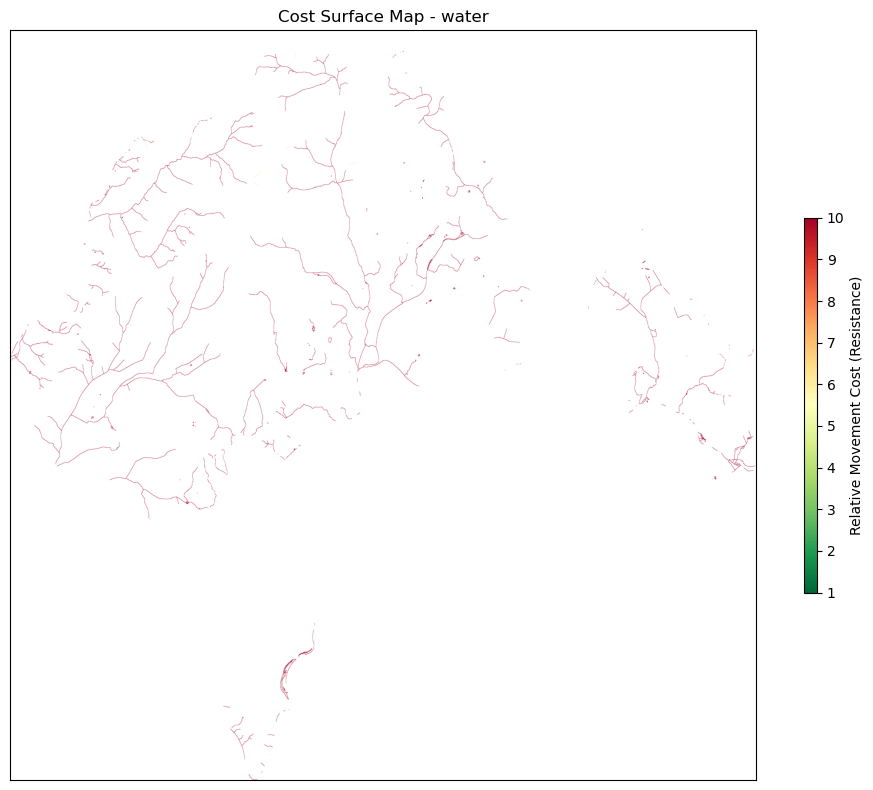

In [61]:
visualize_cost_surface(cost_surface_water, 'water', sh_bbox)

Roads

In [38]:
layers = fiona.listlayers(tlm_path)
print(f"tlm layers: {layers}") 

tlm layers: ['tlm_strassen_aus_einfahrt', 'tlm_bb_bodenbedeckung', 'tlm_bb_einzelbaum_gebuesch', 'tlm_eo_einzelobjekt', 'tlm_oev_eisenbahn', 'tlm_gewaesser_fliessgewaesser', 'tlm_namen_flurname', 'tlm_areale_freizeitareal', 'tlm_bauten_gebaeude_footprint', 'tlm_namen_gebietsname', 'tlm_name_gelaendename', 'tlm_oev_haltestelle', 'tlm_bauten_leitung', 'tlm_bauten_mauer', 'tlm_namen_name_pkt', 'tlm_areale_nutzungsareal', 'tlm_oev_schifffahrt', 'tlm_areale_schutzgebiet', 'tlm_namen_siedlungsname', 'tlm_bauten_sportbaute_lin', 'tlm_bauten_sportbaute_ply', 'tlm_bauten_staubaute', 'tlm_gewaesser_stehendes_gewaesser', 'tlm_strassen_strasse', 'tlm_strassen_strasseninfo', 'tlm_oev_uebrige_bahn', 'tlm_bauten_verbauung', 'tlm_areale_verkehrsareal', 'tlm_bauten_verkehrsbaute_lin', 'tlm_bauten_verkehrsbaute_ply', 'tlm_bauten_versorgungsbaute_pkt', 'tlm_bb_glamos', 'tlm_bauten_leitung_stromtrasse', 'tlm_areale_nutzungsareal_schule', 'tlm_areale_schule', 'tlm_strassen_strassenname', 'tlm_strassen_stra

In [39]:

roads_sh = load_swisstlm_for_canton("tlm_strassen_strasse", sh_bbox, sh)


In [40]:
roads_en = {
    '10m Strasse': '10m Road', 
    '8m Strasse': '8m Road', 
    '6m Strasse': '6m Road', 
    '4m Strasse': '4m Road',
    '3m Strasse': '3m Road', 
    '2m Weg': '2m Path', 
    '1m Weg': '1m Path', 
    '2m Wegfragment': '2m Path Fragment',
    '1m Wegfragment': '1m Path Fragment', 
    'Autostrasse': 'Expressway',
    'Ausfahrt': 'Exit', 
    'Einfahrt': 'Entrance', 
    'Dienstzufahrt': 'Service Access', 
    'Zufahrt': 'Access Road', 
    'Verbindung': 'Connection', 
    'Platz': 'Square/Plaza', 
    'Raststaette': 'Rest Stop', 
    'Faehre': 'Ferry'
}
    
roads_sh['Standard_Name'] = roads_sh['objektart'].map(roads_en)

In [41]:
road_cost_map = {
    '10m Road': 10, 
    '8m Road': 10, 
    '6m Road': 9, 
    '4m Road': 8,
    '3m Road': 7, 
    '2m Path': 6, 
    '1m Path': 5, 
    '2m Path Fragment': 4,
    '1m Path Fragment': 3, 
    'Expressway': 10, 
    'Exit': 10, 
    'Entrance': 10, 
    'Service Access': 8, 
    'Access Road': 8, 
    'Connection': 8, 
    'Square/Plaza': 5, 
    'Rest Stop': 6, 
    'Ferry': 10
}

roads_sh['cost_value'] = roads_sh['Standard_Name'].map(road_cost_map)

In [42]:
cost_surface_roads = rasterize_vectordata(data = roads_sh, bbox = sh_bbox)

C:\Users\Lukas\AppData\Local\Temp\ipykernel_4720\3080590101.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


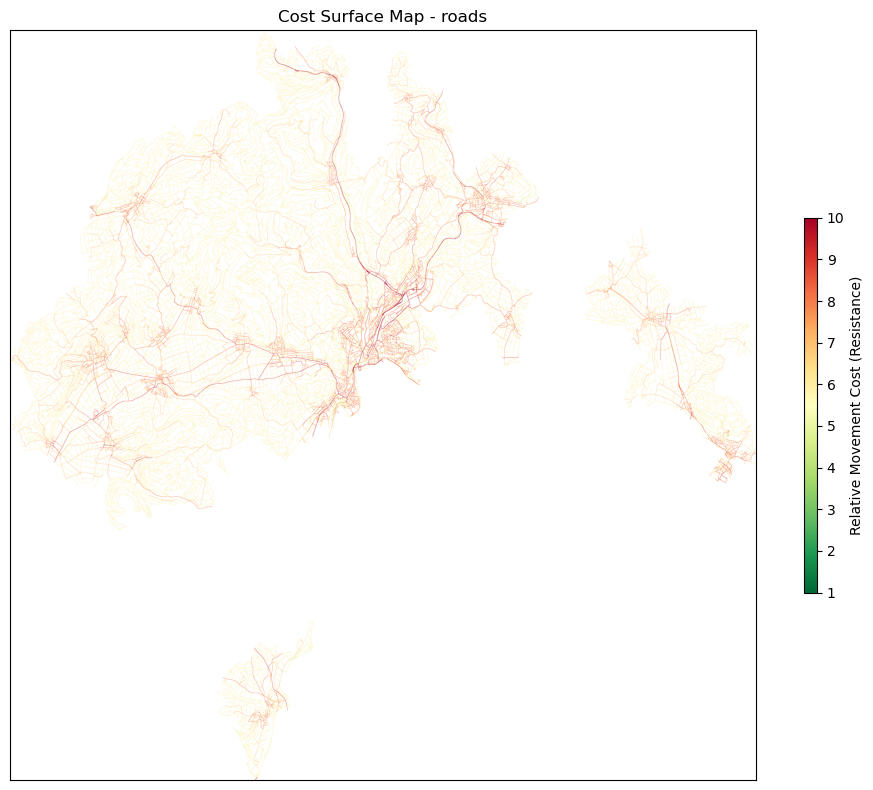

In [62]:
visualize_cost_surface(cost_surface_roads, 'roads', sh_bbox)

Steepness

evtl. Noise

Final Model

In [44]:
# Da alle drei Faktoren den Wert 1 haben (einfache Addition):
# Wir verwenden np.dstack, um die drei 2D-Arrays zu einem 3D-Array zu stapeln (Stacken).
stacked_arrays = np.dstack((cost_surface_landcover, cost_surface_water, cost_surface_roads))

# np.nansum entlang der dritten Achse (Achse=2) summiert die Pixelwerte
# und ignoriert dabei alle NaN-Werte.
final_cost_surface_array = np.nansum(stacked_arrays, axis=2)

# --- 3. ERGEBNISPRÜFUNG ---
print("✅ NaN-sichere Addition der Kostenoberflächen erfolgreich durchgeführt.")
print(f"Form des finalen Arrays: {final_cost_surface_array.shape}")

# Da die Eingabewerte zwischen 1 und 10 liegen, sind die Bereiche:
# Min. möglicher Wert: 1 (wenn zwei der drei Faktoren NaN sind)
# Max. möglicher Wert: 30 (wenn kein Faktor NaN ist)
print(f"Datenbereich (Min/Max): {final_cost_surface_array[~np.isnan(final_cost_surface_array)].min():.2f} / {final_cost_surface_array.max():.2f}")

# Wenn alle drei Faktoren an einer Stelle NaN waren, ist das Ergebnis 0.0. 
# Dies kannst du später anpassen, falls du NaN statt 0.0 wünschst.
print(f"Anzahl der Pixel mit Wert 0 (alle Nan oder 0 in Eingabe): {np.sum(final_cost_surface_array == 0)}")

✅ NaN-sichere Addition der Kostenoberflächen erfolgreich durchgeführt.
Form des finalen Arrays: (2849, 3547)
Datenbereich (Min/Max): 0.00 / 30.00
Anzahl der Pixel mit Wert 0 (alle Nan oder 0 in Eingabe): 7115003


C:\Users\Lukas\AppData\Local\Temp\ipykernel_4720\3135178755.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


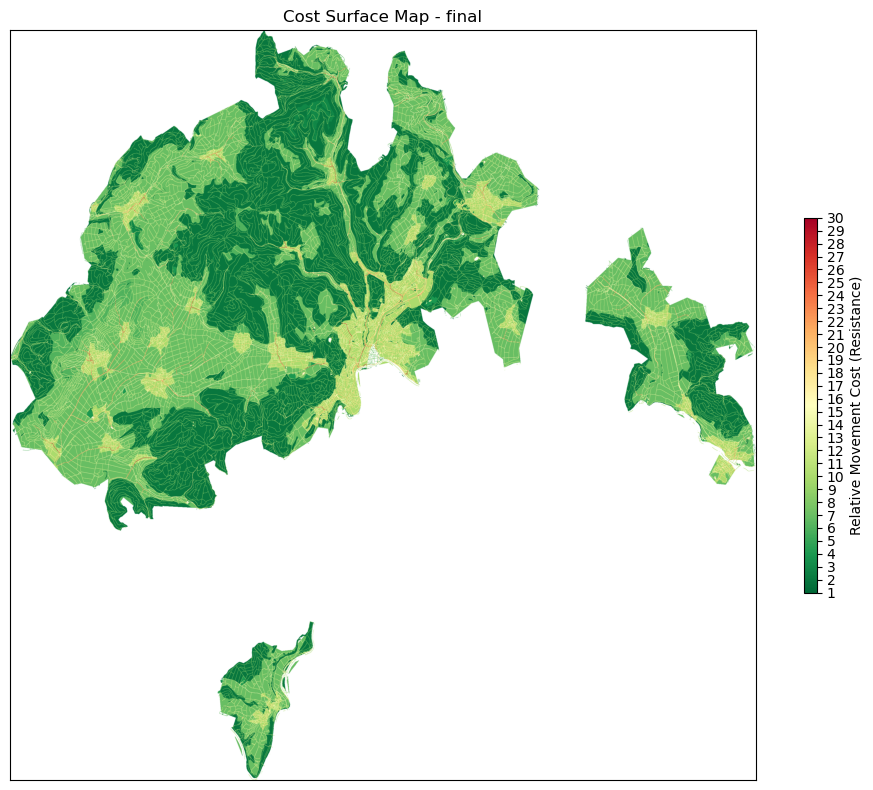

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

cmap_name = 'RdYlGn_r'

# 1. Colormap kopieren und die Farbe für 'schlechte/maskierte' Daten setzen
# Wir erstellen eine Kopie, um die globale Colormap nicht zu verändern
cmap = plt.cm.get_cmap(cmap_name).copy() 
cmap.set_bad('white') 

# 2. Maskiertes Array erstellen: Alle 0-Werte maskieren (als ungültig behandeln)
masked_data = np.ma.masked_where(final_cost_surface_array == 0, final_cost_surface_array)

image = ax.imshow(
    masked_data, # Verwende das maskierte Array
    cmap=cmap,              
    extent=[sh_bbox[0], sh_bbox[1], sh_bbox[2], sh_bbox[3]],
    vmin=1,
    vmax=30)

cbar = fig.colorbar(
image, 
ax=ax, 
ticks=np.arange(1, 31, 1),
shrink=0.5,
aspect=30)

cbar.set_label('Relative Movement Cost (Resistance)')

# Achsenelemente für Kartenansicht entfernen
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

ax.set_title(f'Cost Surface Map - final')

plt.tight_layout()